## Lab 5: Quantitative Evaluation of Fine-tuned Models

**⏱️ Estimated completion time: 5 minutes**

### Lab overview

Brief: This lab demonstrates how to perform quantitative evaluation of your fine-tuned Nova-Lite model against the pre-trained baseline using the ANLS* (Average Normalized Levenshtein Similarity) metric. You'll conduct batch inference on unseen test data and compare model performance to validate the effectiveness of your fine-tuning approach.

Expected outputs: ANLS* scores for both fine-tuned and pre-trained models, with comparative analysis showing the improvement achieved through fine-tuning on document VQA tasks.

**Key Learning Objectives:**
- Understand quantitative evaluation methodologies for multimodal models
- Learn about ANLS* metric for document understanding tasks
- Experience batch inference workflows with Bedrock
- Compare fine-tuned vs pre-trained model performance
- Practice proper model evaluation and cleanup procedures

**Workshop Progress:**
- ✅ Lab 1: Data Preparation
- ✅ Lab 2: Fine-tuning Nova-Lite   
- ✅ Lab 3: Import & Deploy to Bedrock  
- ✅ Lab 4: Inference & Qualitative Testing  
- ⏳ Lab 5: Quantitative Evaluation (5 mins) ← 📍 You are here

### 🎯 Workshop Context

Model evaluation is a critical step in the ML lifecycle that validates whether your fine-tuning efforts have improved model performance on your specific task. In this lab, you'll use the test dataset (unseen during training) to objectively measure your model's document understanding capabilities.

**Why quantitative evaluation matters:**
- Provides objective performance metrics
- Validates fine-tuning effectiveness
- Enables comparison between model variants
- Supports data-driven deployment decisions


### Prerequisites
- You have already run Labs 1-4.

### 1 — Restore deployment ARN from previous lab

Brief: Retrieve the custom model deployment ARN that was stored in the previous notebook. This ARN is required to send inference requests to your deployed fine-tuned model.

Why we're doing this: The deployment ARN serves as the endpoint identifier for your custom model in Bedrock. Without this ARN, we cannot send inference requests to evaluate the fine-tuned model's performance.

What to check after running: Verify the ARN is successfully retrieved and points to your custom Nova-Lite model deployment.

⚠️ Note: 

Please select the following **Python Environment** to run this notebook.

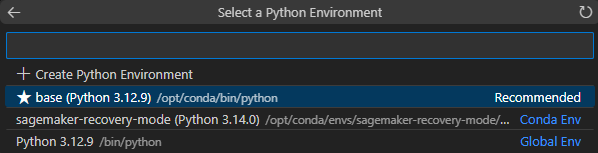

In [ ]:
%store -r custom_model_deployment_arn
custom_model_deployment_arn

### 2 — Quantitatively evaluation of the Fine tuned model

**Overview**

The main objective here is to evaluate the fine-tuned model's performance on the Test dataset that it has never seen before. There are several techniques and metrics to do this, we will go through a commonly used method called ANLS* (often pronounced "anls-star"). 

ANLS* (Average Normalized Levenshtein Similarity) refers to a universal metric used to evaluate the performance of generative large language models on document processing tasks. It is an extension of the ANLS (Average Normalized Levenshtein Similarity) metric, designed to handle more complex, structured, and unstructured outputs. 

How ANLS* works: 

ANLS* compares a model's "Prediction" against the "Ground Truth" (the correct answer). It is normalized to produce a score between 0 and 1, with a higher number indicating greater accuracy. 
The metric evaluates predictions in a more flexible way than a simple binary (right or wrong) system. 

For example:

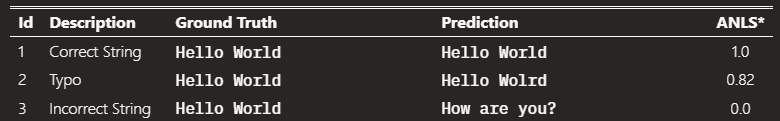

For more details see- [ANLS* - A Universal Document Processing Metric for Generative Large Language Models](https://arxiv.org/html/2402.03848v3).


**🔍 Key Steps:**


1. We are going to send inference requests using the test images to the fine-tuned Nova-Lite model deployed on Bedrock.

2. We will capture the responses along with the prompt sent, and the ground truth for comparison and scoring. 

2. Results will be saved in ./Nova_DocVQA_local/test/test_results_custom.json.   

3. Similarly we'll capture the resonses of the pretrained Nova-lite model in ./Nova_DocVQA_local/test/test_results_pretrained.json

4. Finally, calculate the ANLS* score for both the models and compare them. 


### 3 — Batch inference requests to the custom Nova-lite model endpoint

Brief: Execute batch inference requests against your fine-tuned Nova-Lite model using the test dataset. This generates predictions that will be compared against ground truth answers to calculate performance metrics.

Why we're doing this: To evaluate model performance, we need to collect predictions on unseen test data. The batch_inference_to_file function processes multiple test samples efficiently, capturing prompts, model responses, and ground truth for subsequent analysis.

References:
- [Bedrock Inference API](https://docs.aws.amazon.com/bedrock/latest/userguide/inference.html)
- [Document VQA Evaluation Best Practices](https://arxiv.org/html/2402.03848v3)

⚠️ Note:

Set `n_samples=5` in case you encounter Bedrock RPM (Requests per min) quota issues. 

In [ ]:
from utils.batch_inference import batch_inference_to_file

batch_inference_to_file(
    metadata_path="./Nova_DocVQA_local/test/test.jsonl", # Test Data set prepared in 1_data_prep.ipynb.
    model=custom_model_deployment_arn, # ARN of the custom model deployed
    output_file="./Nova_DocVQA_local/test/test_results_custom.json", # capture Prompt, Response and gnd truth
    n_samples=20, # these are the number of test images that we'll send for inference
    region_name="us-east-1"
)

### 4 — Batch inference on pre-trained baseline model

Brief: Execute the same batch inference process using the pre-trained Nova-Lite model (amazon.nova-lite-v1:0) as a baseline for comparison. This establishes the performance benchmark before fine-tuning.

Why we're doing this: Comparing against the pre-trained baseline is essential to demonstrate the value of fine-tuning. Without this comparison, we cannot quantify the improvement achieved through domain-specific training on document VQA tasks.

⚠️ Note:

Set `n_samples=5` in case you encounter Bedrock RPM (Requests per min) quota issues. 

In [ ]:
pretrained_model_id = "amazon.nova-lite-v1:0"

batch_inference_to_file(
    metadata_path="./Nova_DocVQA_local/test/test.jsonl",
    model=pretrained_model_id,
    output_file="./Nova_DocVQA_local/test/test_results_pretrained.json",
    n_samples=20, 
    region_name="us-east-1"
)

### 5 — Calculate ANLS* score for fine-tuned model

Brief: Compute the ANLS* (Average Normalized Levenshtein Similarity) score for your fine-tuned model by comparing its predictions against ground truth answers from the test dataset.

Why we're doing this: ANLS* provides a standardized metric for evaluating text generation quality in document understanding tasks. It accounts for partial matches and character-level similarities, giving a more nuanced view of model performance than binary accuracy.

What to check after running: Note the ANLS* score (0-1 scale) for your fine-tuned model. Higher scores indicate better alignment between predictions and ground truth answers.

In [ ]:
# Calculate ANLS metric
from utils.anls_calculation import calculate_anls_from_file

# Calculate ANLS for the custom model 
anls_score = calculate_anls_from_file("./Nova_DocVQA_local/test/test_results_custom.json")


### 6 — Calculate ANLS* score for pre-trained baseline

Brief: Compute the ANLS* score for the pre-trained Nova-Lite model using the same evaluation methodology applied to your fine-tuned model.

Why we're doing this: The baseline ANLS* score establishes the starting point performance before fine-tuning. Comparing this with your fine-tuned model's score quantifies the improvement achieved through domain-specific training.

What to check after running: Compare the baseline ANLS* score with your fine-tuned model's score. A higher score for the fine-tuned model indicates successful knowledge transfer and task-specific optimization.

In [ ]:
# Calculate ANLS for the Pretrianed model 

anls_score = calculate_anls_from_file("./Nova_DocVQA_local/test/test_results_pretrained.json")

## 7 — 📊 Model Performance Comparison Summary 

### ANLS* Score Comparison for 20 Test samples 
| Model Version | ANLS* Score |
|--------------|-------------|
| Pre-trained Nova-Lite | 0.2108 |
| Fine-tuned Nova-Lite | 0.8639 |

**⚠️ Note**: 
- You may see slightly different results since your test split has a different set of images.
- ANLS* (Average Normalized Levenshtein Similarity) scores range from 0 to 1, where higher scores indicate better performance.

### Key Findings
- The fine-tuned model showed a **~309% improvement** in ANLS* score
- Demonstrated better accuracy on document-specific questions
- More consistent performance across different question types
- Improved handling of complex document layouts

### Impact
This significant improvement validates our fine-tuning approach and shows the model's enhanced capability in document understanding tasks. The fine-tuned model is better equipped to handle domain-specific document Q&A scenarios.




## 🎉 Lab 5 Complete!

**Congratulations!** You have successfully completed the quantitative evaluation of your fine-tuned Nova model. Here's what you accomplished:

### ✅ Tasks Completed:
1. **Model Setup** - Retrieved and validated custom model deployment ARN
2. **Batch Inference** - Executed inference requests on test dataset
3. **Performance Evaluation** - Implemented ANLS* metric calculations
4. **Comparative Analysis** - Assessed fine-tuned vs pre-trained model performance
5. **Results Documentation** - Captured and stored evaluation metrics
6. **Model Validation** - Verified improvements from fine-tuning
7. **Test Data Processing** - Evaluated model on unseen examples
8. **Results Storage** - Saved evaluation outputs for future reference

### 📊 Key Outputs:
- **Test Results**: Comprehensive evaluation on test dataset
- **Performance Metrics**: ANLS* scores for both model variants

### 🚀 Next Steps:
- **Production Deployment**: Consider deploying the better-performing model
- **Continuous Evaluation**: Set up ongoing performance monitoring
- **Further Fine-tuning**: Identify areas for additional improvement
- **Scale Testing**: Expand evaluation to larger test sets

_______________________________________________________________________________

## 🎯 Workshop Summary
_______________________________________________________________________________

Throughout this workshop, you've progressed through several key phases of building and evaluating a custom document Q&A model:

### Lab 1: Data Preparation (Lab1_data_prep)
- Set up the environment and explored DocumentVQA dataset
- Transformed data into Nova-compatible format
- Organized and uploaded data to S3
- Created train/validation/test splits

### Lab 2: Model Training (Lab2_train)
- Configured and Launched Nova-Lite model fine-tuning
- Monitored training progress
- Analyzed training metrics and logs
- Visualized training results

### Lab 3: Model Deployment (Lab3_import_deploy)
- Import fine-tuned model to Bedrock
- Deploy the model for on-demand inference

### Lab 4: Inference Testing (Lab4_inference_testing)
- Tested model with real-world examples 
- Validated model responses interactively using the Test App

### Lab 5: Quantitative Evaluation (Lab5_quantitative_evals)
- Performed quantitative testing on Test dataset
- Evaluated model using ANLS* metrics
- Compared performance with baseline model
- Generated evaluation reports
_______________________________________________________________________________

## 🙏 Thank You!

Thank you for participating in this Nova fine-tuning workshop! We hope you've gained valuable insights. 

We encourage you to apply these learnings to your own use cases and continue exploring the capabilities of Amazon SageMaker, Bedrock and Nova models.

**Happy Building! 🚀**
